In [1]:
from kipy import KiCad
from kipy.geometry import Vector2, Angle
from kipy.board_types import (
    BoardLayer,
    BoardSegment,
    BoardRectangle,
    BoardCircle,
    BoardArc,
    BoardPolygon,
    to_concrete_board_shape,
)
from dataclasses import dataclass, field
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch

if __name__ == "__main__":
    try:
        kicad = KiCad()
        print(f"Connected to KiCad {kicad.get_version()}")
    except BaseException as e:
        print(f"Not connected to KiCad: {e}")

Connected to KiCad 10.0.1 (10.0.1)


In [2]:
@dataclass
class Pin:
    local_pos: np.ndarray
    net: str


@dataclass
class Component:
    id: str
    pos: np.ndarray
    theta: float = 0.0
    half_size: np.ndarray = field(default_factory=lambda: np.array([2.5, 2.5]))
    pins: list = field(default_factory=list)
    fixed: bool = False

def rot(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s], [s, c]])


def pin_world(comp, pin):
    return comp.pos + rot(comp.theta) @ pin.local_pos


def rebuild_nets(components):
    nets = {}
    for cid, comp in components.items():
        for pi, pin in enumerate(comp.pins):
            nets.setdefault(pin.net, []).append((cid, pi))
    return nets


def hpwl(components):
    total = 0.0
    for members in rebuild_nets(components).values():
        if len(members) < 2:
            continue
        pts = np.array(
            [pin_world(components[c], components[c].pins[p]) for c, p in members]
        )
        total += np.ptp(pts[:, 0]) + np.ptp(pts[:, 1])
    return total

def draw(components, board, title="", ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 6))
    ax.set_aspect("equal")
    ax.set_title(title)
    ax.add_patch(patches.Polygon(board, facecolor="#f6f6e8", edgecolor="#444"))
    for net, members in rebuild_nets(components).items():
        if len(members) < 2:
            continue
        pts = [pin_world(components[c], components[c].pins[p]) for c, p in members]
        ctr = np.mean(pts, axis=0)
        for p in pts:
            ax.plot(
                [p[0], ctr[0]], [p[1], ctr[1]], "-", color="#6b6", alpha=0.6, lw=0.8
            )
    for cid, c in components.items():
        box = np.array([[-1, -1], [1, -1], [1, 1], [-1, 1]]) * c.half_size
        corners = (rot(c.theta) @ box.T).T + c.pos
        color = "#fcc" if c.fixed else "#cce"
        ax.add_patch(patches.Polygon(corners, facecolor=color, edgecolor="#225"))
        ax.text(*c.pos, cid, ha="center", va="center", fontsize=6.5)
        for p in c.pins:
            ax.plot(*pin_world(c, p), "o", color="#225", markersize=2)
    ax.autoscale_view()
    ax.grid(alpha=0.2)
    return ax

In [3]:
board = kicad.get_board()
footprints = board.get_footprints()

# for f in footprints:
    # print(f"{f.reference_field.text.value}")

In [4]:
# Get board

def n2m(v):
    NM = 1e6  # nanometres per millimetre
    return np.array([v.x, v.y]) / NM

def rect(lo, hi):
    lo, hi = np.asarray(lo, float), np.asarray(hi, float)
    return np.array([lo, [hi[0], lo[1]], hi, [lo[0], hi[1]]])

# builtin version
# def get_edge_cuts(board):
#     shape = next((s for s in board.get_shapes() if s.layer == BoardLayer.BL_Edge_Cuts), None)
#     if not shape:
#         return None
#     box = board.get_item_bounding_box(shape)
#     if not box: raise Error
#     return rect(n2m(box.pos), n2m(box.pos) + n2m(box.size))

def get_edge_cuts(board):
    box = None
    for s in board.get_shapes():
        if s.layer == BoardLayer.BL_Edge_Cuts:
            b = to_concrete_board_shape(s).bounding_box()
            box = b if box is None else (box.merge(b) or box)  # merge mutates, returns None
    if box is None:
        return None
    lo = n2m(box.pos)
    return rect(lo, lo + n2m(box.size))

get_edge_cuts(board)

array([[100.,  44.],
       [165.,  44.],
       [165., 100.],
       [100., 100.]])

In [5]:
def calc_half_size(board, fp):
    CRTYD = (BoardLayer.BL_F_CrtYd, BoardLayer.BL_B_CrtYd)
    box = None
    for s in fp.definition.shapes:
        if s.layer in CRTYD:
            b = to_concrete_board_shape(s).bounding_box()
            box = b if box is None else (box.merge(b) or box)
        if box is None:
            box = board.get_item_bounding_box(fp)
        return n2m(box.size) / 2 if box is not None else np.array([0.5, 0.5])
    
def get_components(board):
    components = {}
    for fp in board.get_footprints():
        ref = fp.reference_field.text.value
        pos = n2m(fp.position)
        theta = fp.orientation.to_radians()
        Rinv = rot(-theta)
        pins = [Pin(local_pos=Rinv @ (n2m(p.position) - pos), net=p.net.name)
                for p in fp.definition.pads]
        components[ref] = Component(
            id=ref,
            pos=pos,
            theta=theta,
            half_size=calc_half_size(board, fp),
            pins=pins,
            fixed=fp.locked,
        )
    return components
# get_components(board)

<Axes: >

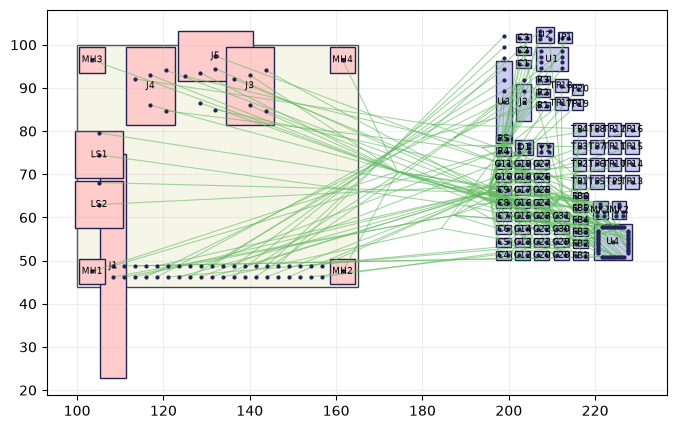

In [6]:
draw(get_components(board), get_edge_cuts(board))

In [7]:
def place(
    components,
    edges,
    n_iters=1000,
    lr_pos=None,
    lr_theta=0.05,
    gamma=1.0,
    M=64,
    lam_max=50.0,
    verbose=True,
):
    """Optimize positions + rotations in place. Returns (components, history)."""
    ids = list(components)
    hs = torch.tensor(
        np.array([components[c].half_size for c in ids]), dtype=torch.float32
    )
    pos = torch.tensor(
        np.array([components[c].pos for c in ids]),
        dtype=torch.float32,
        requires_grad=True,
    )
    theta = torch.tensor(
        [components[c].theta for c in ids], dtype=torch.float32, requires_grad=True
    )
    fixed = torch.tensor([components[c].fixed for c in ids])
    fixed_pos = pos.detach().clone()
    fixed_theta = theta.detach().clone()

    lo = torch.tensor(edges[0], dtype=torch.float32)
    hi = torch.tensor(edges[2], dtype=torch.float32)
    if lr_pos is None:
        lr_pos = 0.005 * float((hi - lo).max())  # step ~0.5% of board per iter
    part_area = float((4 * hs[:, 0] * hs[:, 1]).sum())
    tol = 0.02 * part_area  # tolerate 2% overlapped area

    net_pins = []
    for members in rebuild_nets(components).values():
        if len(members) < 2:
            continue
        net_pins.append(
            [
                (
                    ids.index(cid),
                    torch.tensor(
                        components[cid].pins[pi].local_pos, dtype=torch.float32
                    ),
                )
                for cid, pi in members
            ]
        )

    def pin_pos(i, off):
        c, s = torch.cos(theta[i]), torch.sin(theta[i])
        return pos[i] + torch.stack([c * off[0] - s * off[1], s * off[0] + c * off[1]])

    def hs_eff():
        c, s = torch.cos(theta).abs(), torch.sin(theta).abs()
        return torch.stack(
            [c * hs[:, 0] + s * hs[:, 1], c * hs[:, 1] + s * hs[:, 0]], dim=1
        )

    def wa_wirelength():
        total = 0.0
        for members in net_pins:
            pts = torch.stack([pin_pos(i, off) for i, off in members])
            for d in range(2):
                x = pts[:, d]
                total = (
                    total
                    + (x * torch.softmax(x / gamma, 0)).sum()
                    - (x * torch.softmax(-x / gamma, 0)).sum()
                )
        return total

    bx = torch.linspace(lo[0], hi[0], M + 1)
    by = torch.linspace(lo[1], hi[1], M + 1)
    bin_area = (bx[1] - bx[0]) * (by[1] - by[0])

    def density_map():
        h = hs_eff()
        ox = (
            torch.minimum(pos[:, 0:1] + h[:, 0:1], bx[None, 1:])
            - torch.maximum(pos[:, 0:1] - h[:, 0:1], bx[None, :-1])
        ).clamp(min=0)
        oy = (
            torch.minimum(pos[:, 1:2] + h[:, 1:2], by[None, 1:])
            - torch.maximum(pos[:, 1:2] - h[:, 1:2], by[None, :-1])
        ).clamp(min=0)
        return torch.einsum("ni,nj->ij", ox, oy) / bin_area

    def electro_energy(rho):
        q = (rho - 1.0).clamp(min=0)  # only over-capacity density is charge
        q = q - q.mean()  # neutralize for the periodic solve
        fx = torch.fft.fftfreq(M) * 2 * np.pi
        k2 = fx[:, None] ** 2 + fx[None, :] ** 2
        k2[0, 0] = 1.0
        phi = torch.fft.ifft2(torch.fft.fft2(q) / k2).real
        return 0.5 * (q * phi).sum()

    opt = torch.optim.Adam(
        [{"params": [pos], "lr": lr_pos}, {"params": [theta], "lr": lr_theta}]
    )
    lam, snap_w = 1e-3, 0.0
    history = {"wl": [], "den": [], "overflow": [], "lam": []}

    for it in range(n_iters):
        opt.zero_grad()
        wl = wa_wirelength()
        den = lam * electro_energy(density_map())
        snap = snap_w * torch.sin(2 * theta).pow(2).sum()
        (wl + den + snap).backward()
        opt.step()
        with torch.no_grad():
            pos.data[fixed] = fixed_pos[fixed]
            theta.data[fixed] = fixed_theta[fixed]
            h = hs_eff()
            pos.data = torch.max(torch.min(pos, hi - h), lo + h)
            overflow = ((density_map() - 1.0).clamp(min=0).sum() * bin_area).item()
        if overflow > tol:
            lam = min(lam * 1.03, lam_max)
        elif overflow < 0.5 * tol:
            lam *= 0.97
        if it > 0.4 * n_iters:
            snap_w = min(snap_w + 0.02, 5.0)
        history["wl"].append(wl.item())
        history["den"].append(den.item())
        history["overflow"].append(overflow)
        history["lam"].append(lam)
        if verbose and it % 100 == 0:
            print(
                f"it {it:4d}  WL {wl.item():9.2f}  lam*density {den.item():8.2f}  "
                f"lam {lam:.4f}  overflow {overflow:7.2f}"
            )

    with torch.no_grad():  # legalize rotation
        theta.data = torch.round(theta / (np.pi / 2)) * (np.pi / 2)
        theta.data[fixed] = fixed_theta[fixed]
        h = hs_eff()
        pos.data = torch.max(torch.min(pos, hi - h), lo + h)

    p, t = pos.detach().numpy(), theta.detach().numpy()
    for i, cid in enumerate(ids):
        components[cid].pos = p[i].astype(float)
        components[cid].theta = float(t[i])
    return components, history

82 components, initial HPWL = 4789.1
it    0  WL   4780.05  lam*density     1.03  lam 0.0010  overflow  797.93
it  100  WL   1042.16  lam*density    80.54  lam 0.0198  overflow  435.56
it  200  WL   1060.42  lam*density   588.03  lam 0.3804  overflow  289.77
it  300  WL   1288.44  lam*density  8573.79  lam 7.3115  overflow  432.96
it  400  WL   1581.83  lam*density 44694.40  lam 50.0000  overflow  614.11
it  500  WL   1577.70  lam*density 44505.48  lam 50.0000  overflow  610.59
it  600  WL   1577.91  lam*density 44492.71  lam 50.0000  overflow  611.57
it  700  WL   1577.18  lam*density 44495.32  lam 50.0000  overflow  610.06
it  800  WL   1577.19  lam*density 44499.79  lam 50.0000  overflow  610.37
it  900  WL   1578.09  lam*density 44487.69  lam 50.0000  overflow  611.21


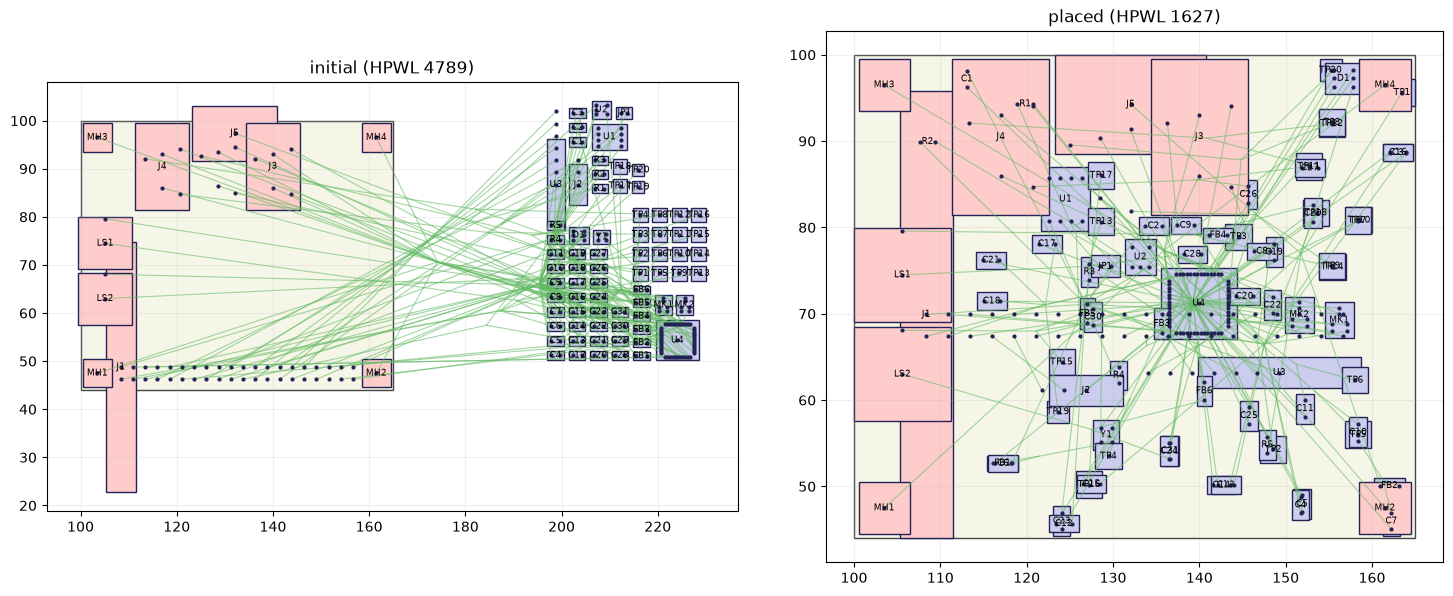

In [8]:
components, edges = get_components(board), get_edge_cuts(board)
print(f"{len(components)} components, initial HPWL = {hpwl(components):.1f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
draw(components, edges, f"initial (HPWL {hpwl(components):.0f})", axes[0])
place(components, edges)
draw(components, edges, f"placed (HPWL {hpwl(components):.0f})", axes[1])
plt.tight_layout()

In [9]:
get_edge_cuts(board)

array([[100.,  44.],
       [165.,  44.],
       [165., 100.],
       [100., 100.]])

In [10]:
for s in board.get_shapes():
    if s.layer == BoardLayer.BL_Edge_Cuts:
        c = to_concrete_board_shape(s)
        b = c.bounding_box()
        print(type(c).__name__, n2m(b.pos), n2m(b.size))

BoardSegment [100.  47.] [ 0. 16.]
BoardArc [100.  44.] [3. 3.]
BoardSegment [100.  63.] [ 0. 18.]
BoardSegment [100.  81.] [ 0. 16.]
BoardArc [100.  97.] [3. 3.]
BoardSegment [103. 100.] [59.  0.]
BoardSegment [103.  44.] [59.  0.]
BoardArc [162.  44.] [3. 3.]
BoardArc [162.  97.] [3. 3.]
BoardSegment [165.  47.] [ 0. 50.]
